### Molecular reaction barriers


We will consider a simple example of the barrier for NH<sub>3</sub> inversion. We have to create an NH<sub>3</sub> molecule in the initial and inverted state (these have exactly the same energy), and then interpolate a band of images. Then, we use the NEB method cite:sheppard:134106 to compute the barrier to inversion. The NEB class of methods are pretty standard, but other algorithms for finding barriers (saddle-points) exist that may be relevant cite:olsen:9776.



#### Get initial and final states



In [1]:
# compute initial and final states
from ase import Atoms
from ase.build import molecule
import numpy as np
from vasp import Vasp
from ase.constraints import FixAtoms

atoms = molecule('NH3')
constraint = FixAtoms(mask=[atom.symbol == 'N' for atom in atoms])
atoms.set_constraint(constraint)

Npos = atoms.positions[0]

# move N to origin
atoms.translate(-Npos)
atoms.set_cell((10, 10, 10), scale_atoms=False)

atoms2 = atoms.copy()
pos2 = atoms2.positions

for i,atom in enumerate(atoms2):
    if atom.symbol == 'H':
        # reflect through z
        pos2[i] *= np.array([1, 1, -1])
atoms2.positions = pos2

#now move N to center of box
atoms.translate([5, 5, 5])
atoms2.translate([5, 5, 5])

calcs = [Vasp(label='molecules/nh3-initial',
              xc='PBE',
              encut=350,
              ibrion=1,
              nsw=10,
              atoms=atoms),
         Vasp(label='molecules/nh3-final',
             xc='PBE',
             encut=350,
             ibrion=1,
             nsw=10,
             atoms=atoms2)]

print([c.potential_energy for c in calcs])

[-19.44508478, -19.44508478]


#### Run band calculation



Now we do the band calculation.



[Atoms(symbols='NH3', pbc=True, cell=[10.0, 10.0, 10.0], constraint=FixAtoms(indices=[0])), Atoms(symbols='NH3', pbc=True, cell=[10.0, 10.0, 10.0], constraint=FixAtoms(indices=[0])), Atoms(symbols='NH3', pbc=True, cell=[10.0, 10.0, 10.0], constraint=FixAtoms(indices=[0])), Atoms(symbols='NH3', pbc=True, cell=[10.0, 10.0, 10.0], constraint=FixAtoms(indices=[0])), Atoms(symbols='NH3', pbc=True, cell=[10.0, 10.0, 10.0], constraint=FixAtoms(indices=[0])), Atoms(symbols='NH3', pbc=True, cell=[10.0, 10.0, 10.0], constraint=FixAtoms(indices=[0]))]
[None, -19.25997895, -18.9954933, -18.99549307, -19.25997865, None]


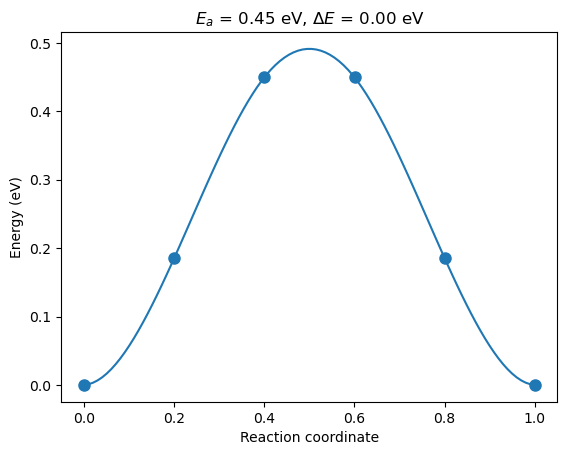

In [2]:
# Run NH3 NEB calculations
from vasp import Vasp
from ase.neb import NEB
from ase.io import read

atoms = Vasp('molecules/nh3-initial').load_atoms()
atoms2 = Vasp('molecules/nh3-final').load_atoms()

# 5 images including endpoints
images = [atoms]   # initial state
images += [atoms.copy() for i in range(4)]
images += [atoms2]  # final state

neb = NEB(images)
neb.interpolate()  # This works by side effect on the list of images

# ! rm -fr molecules/nh3-neb
calc = Vasp('molecules/nh3-neb',
            xc='PBE',
            ibrion=1, 
            encut=350,
            nsw=90,
            spring=-5.0,
            atoms=images)

images, energies = calc.get_neb()


print(images)
print(energies)

# Get energies from endpoint calculations
E_initial = Vasp('molecules/nh3-initial').potential_energy
E_final = Vasp('molecules/nh3-final').potential_energy

# Plot with endpoint energies
calc.plot_neb(initial_energy=E_initial, final_energy=E_final);

huh. this is about twice the barrier I saw before.